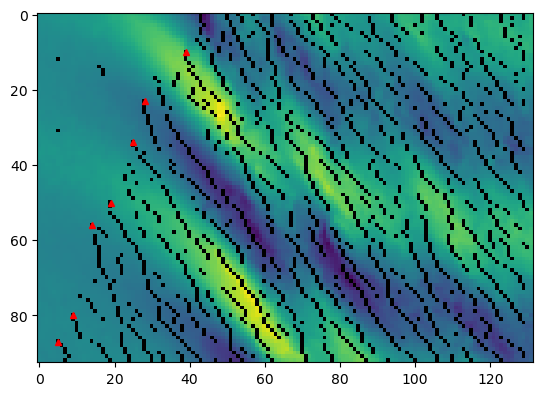

In [8]:
#%% imports modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import pickle
import os
import sys

icewave_path = 'C:/Users/Vasco Zanchi/Documents/git_turbotice/icewave/icewave/'
sys.path.append(icewave_path)

import tools.rw_data as rw

from vasco.tools.clickonfigures import profile_line_on_image_2clicks
from vasco.tools.clickonfigures import get_n_points_onimage
from vasco.tools.clickonfigures import get_n_points
from vasco.tools.clickonfigures import get_n_points_anyfigure

from vasco.field.SagWin2024.fracture_wake_boat.drones.find_wave_front import find_wave_fronts_on_image, find_lines, group_lines_to_dict

#%% definition des chemins des données
#disk = 'L:'# disk is Elements on adour
disk = 'C:'
date = '0211'

#data_path = f'{disk}/Share_hublot/Data'
data_path = f'C:/Users/Vasco Zanchi/Desktop/Saguenay2024'

daily_drone_data_path = f'{data_path}/{date}/Drones'

velocity_field_path = f'{daily_drone_data_path}/exact_solution_real_field_stereo_0211_2024_rectangular_grid.h5'

# traitement stéphane : postitions des fractures (obtenue avec divergence du champ de vitesses)
fractures_positions_path = f'{daily_drone_data_path}/Results/fracture_positions.pkl'

#%% Cellule à exécuter une ceule fois (chargement champs vitesses from stereo piv)
#load dict from h5 file

dict_stereo_pivdata = rw.load_dict_from_h5(velocity_field_path)

#%% chargement des positions des fractures détectées
with open(fractures_positions_path, 'rb') as file:
    fractures_positions_data = pickle.load(file)

# %% definitions des variables utiles (champs d'élévation etc.)
dict_stereo_pivdata.keys()

vx = dict_stereo_pivdata['u'][0,:,:,:]
vy = dict_stereo_pivdata['u'][1,:,:,:]
vz = dict_stereo_pivdata['u'][2,:,:,:]

dt = dict_stereo_pivdata['t'][1] - dict_stereo_pivdata['t'][0]

def detrend_along_time_axis(v, window_size=120): # à peu près nombre de frames par periode d'onde):
    window = np.ones(window_size) / window_size
    v_detrended = np.zeros_like(v)

    # Supposons vz.shape = (N_x, N_y, N_t)
    for i in range(v.shape[0]):
        for j in range(v.shape[1]):
            v_detrended[i, j, :] = v[i, j, :] - np.convolve(v[i, j, :], window, mode='same')
    return v_detrended

vx_detrended = detrend_along_time_axis(vx)
vy_detrended = detrend_along_time_axis(vy)
vz_detrended = detrend_along_time_axis(vz)


ux = np.cumsum(vx_detrended, axis=2)*dt
uy = np.cumsum(vy_detrended, axis=2)*dt
uz = np.cumsum(vz_detrended, axis=2)*dt

facq_x = dict_stereo_pivdata['SCALE']['facq_x']








path_dict2save = f'{daily_drone_data_path}/Results/traitement_vasco/dict_results_frac.pkl'
if os.path.exists(path_dict2save):
    with open(path_dict2save, 'rb') as file:
        dict_frac = pickle.load(file)
image = vz[:,:,1000]
plt.imshow(image)
plt.imshow(np.where(fractures_positions_data['binary'],fractures_positions_data['binary'],np.nan),cmap='gray')

if 'dict_frac' in globals():
    for k in dict_frac:
        if 'single_frac' in k:
            plt.plot(dict_frac[k]['idcs_single_frac'][0][0], dict_frac[k]['idcs_single_frac'][0][1], '^r', markersize=4)
plt.show()


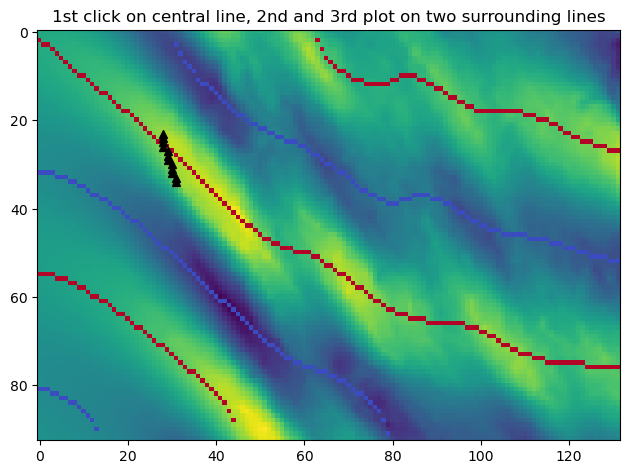

In [12]:
keyfrac = 'dict_single_frac_yind23_xind28'

idcs_single_frac = dict_frac[keyfrac]['idcs_single_frac']
time_frac_approx = dict_frac[keyfrac]['times_frac_sec_approx_ref_noncassee'][0]
index_time_frac_approx = np.where(dict_stereo_pivdata['t']>=time_frac_approx)[0][0]

matrice2d = uz[:,:,index_time_frac_approx]

peaks2d, matrice2d_smoothed = find_wave_fronts_on_image(matrice2d, sigma_smooth=5, axis=0, plot=False)
peaks2d_down, matrice2d_smoothed_down = find_wave_fronts_on_image(-matrice2d, sigma_smooth=5, axis=0, plot=False)


dict_lines_up = group_lines_to_dict(find_lines(peaks2d))
dict_lines_down = group_lines_to_dict(find_lines(peaks2d_down))


fig, ax = plt.subplots()
ax.set_title('1st click on central line, 2nd and 3rd plot on two surrounding lines')
#ax.imshow(matrice2d_smoothed)
ax.imshow(matrice2d)
ax.imshow(peaks2d,cmap='coolwarm',vmax=1,vmin=0) # apparait rouge
ax.imshow(peaks2d_down,cmap='coolwarm',vmin=1) # apparait bleu
ax.plot(idcs_single_frac[:,0], idcs_single_frac[:,1], '^k')
plt.tight_layout()


### Affichage pour article, avec unités physiques :

In [ ]:
def from_pximagecoord_to_physicalcoord(xind,yind,dict_stereo_pivdata=dict_stereo_pivdata):
    X_phys_values = dict_stereo_pivdata['X'][0,:]
    Y_phys_values = dict_stereo_pivdata['Y'][:,0]
    
    xind_values = np.arange(len(X_phys_values))
    yind_values = np.arange(len(Y_phys_values))

    xoutput = np.interp(xind, xind_values, X_phys_values)
    youtput = np.interp(yind, yind_values, Y_phys_values)

    return xoutput, youtput
    
xind_crack_arr = idcs_single_frac[:,0]
yind_crack_arr = idcs_single_frac[:,1]


fig, ax = plt.subplots(figsize=(10,7))
im = ax.pcolormesh(dict_stereo_pivdata['X'],dict_stereo_pivdata['Y'], uz[:,:,ind_tfrac_approx])
im2 = ax.pcolormesh(dict_stereo_pivdata['X'],dict_stereo_pivdata['Y'], np.where(fractures_positions_data['binary'],fractures_positions_data['binary'],np.nan)*-1, vmin=-1, vmax=0, alpha=0.3, cmap='gray')
x_crack_arr, y_crack_arr = from_pximagecoord_to_physicalcoord(xind_crack_arr, yind_crack_arr)
x_refnoncassee, y_ref_noncasse = from_pximagecoord_to_physicalcoord(x_ind_ref_noncasse_int, y_ind_ref_noncasse_int)

ax.set_title('1st click on central line, 2nd and 3rd plot on two surrounding lines')
#ax.imshow(matrice2d_smoothed)
ax.pcolormesh(dict_stereo_pivdata['X'], dict_stereo_pivdata['Y'], matrice2d)
ax.pcolormesh(dict_stereo_pivdata['X'], dict_stereo_pivdata['Y'], peaks2d,cmap='coolwarm',vmax=1,vmin=0) # apparait rouge
ax.pcolormesh(dict_stereo_pivdata['X'], dict_stereo_pivdata['Y'], peaks2d_down,cmap='coolwarm',vmin=1) # apparait bleu
ax.plot(idcs_single_frac[:,0], idcs_single_frac[:,1], '^k')
plt.tight_layout()
